Number of earthquakes: 2325
Observation period (days): 3646.605824641204

Estimated Poisson rate:
lambda = 0.6376 earthquakes/day

Simulated events: 2320


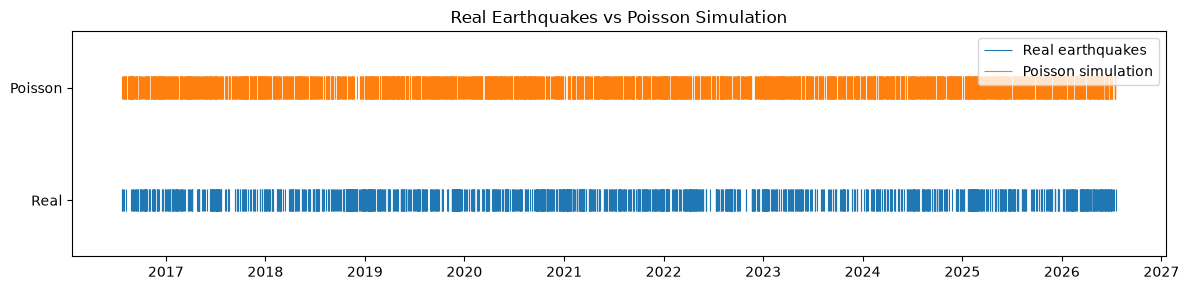

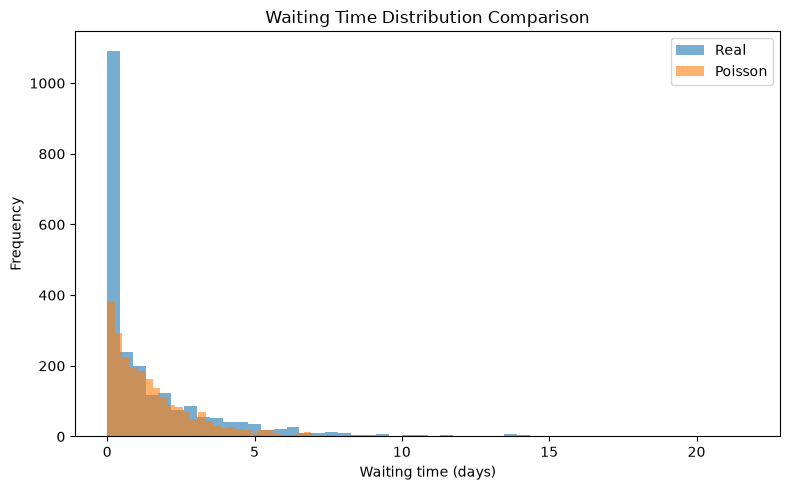

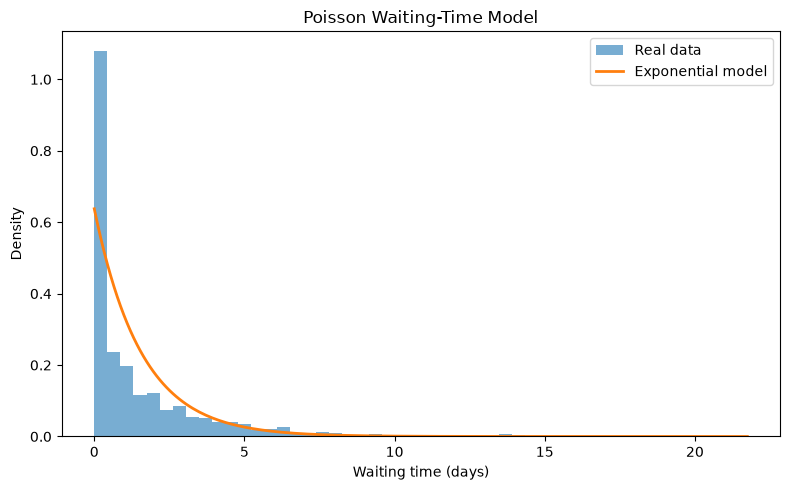


Conclusion:

The Poisson process assumes:

1. Constant earthquake rate
2. Independent events
3. Exponential waiting times

If the real data show many more short waiting times than the
Poisson model predicts, this indicates clustering.

Earthquakes triggering aftershocks violate the Poisson assumption.

The next notebook introduces the Hawkes process, where each
earthquake temporarily increases future earthquake intensity.



In [1]:
# ==============================================================
# Notebook 2: Poisson Process Baseline Model
#
# Goal:
# - Build a simple homogeneous Poisson model
# - Estimate the earthquake rate
# - Simulate earthquake sequences
# - Compare Poisson assumptions with real data
#
# Model:
#
#        N(t) ~ Poisson(lambda * t)
#
# The intensity is constant:
#
#        lambda(t) = lambda
#
# ==============================================================


# --------------------------------------------------------------
# 1. Imports
# --------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# 2. Load data
# --------------------------------------------------------------

df = pd.read_csv("../data/earthquakes_greece_2016_2026.csv")

df["time"] = pd.to_datetime(df["time"])

df = df.sort_values("time").reset_index(drop=True)


# --------------------------------------------------------------
# 3. Compute observation period
# --------------------------------------------------------------

start_time = df["time"].iloc[0]
end_time = df["time"].iloc[-1]

# Total duration in days

T_days = (
    end_time - start_time
).total_seconds() / (24 * 3600)


# Number of earthquakes

n_events = len(df)


print("Number of earthquakes:", n_events)
print("Observation period (days):", T_days)


# --------------------------------------------------------------
# 4. Estimate Poisson rate
# --------------------------------------------------------------
#
# Maximum likelihood estimator:
#
#              lambda_hat = N / T
#
# where:
#   N = number of events
#   T = observation time
#

lambda_hat = n_events / T_days


print("\nEstimated Poisson rate:")
print(f"lambda = {lambda_hat:.4f} earthquakes/day")


# --------------------------------------------------------------
# 5. Simulate Poisson earthquake times
# --------------------------------------------------------------
#
# For a Poisson process:
#
# Waiting times are exponential:
#
#       Delta t ~ Exp(lambda)
#
# We generate waiting times until reaching T.
#

np.random.seed(42)

sim_times = []

current_time = 0

while current_time < T_days:

    waiting_time = np.random.exponential(
        scale=1 / lambda_hat
    )

    current_time += waiting_time

    if current_time < T_days:
        sim_times.append(current_time)


sim_times = np.array(sim_times)


print("\nSimulated events:", len(sim_times))


# --------------------------------------------------------------
# 6. Convert simulated times to dates
# --------------------------------------------------------------

sim_dates = (
    start_time
    +
    pd.to_timedelta(sim_times, unit="D")
)


# --------------------------------------------------------------
# 7. Compare real vs simulated timelines
# --------------------------------------------------------------

plt.figure(figsize=(12, 3))

plt.vlines(
    df["time"],
    0.9,
    1.1,
    linewidth=0.8,
    label="Real earthquakes"
)

plt.vlines(
    sim_dates,
    1.9,
    2.1,
    linewidth=0.8,
    color="C1",
    label="Poisson simulation"
)

plt.yticks([1, 2], ["Real", "Poisson"])
plt.ylim(0.5, 2.5)

plt.title("Real Earthquakes vs Poisson Simulation")
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("../figures/02_real_vs_poisson_timeline.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 8. Compare waiting time distributions
# --------------------------------------------------------------

# Real waiting times

real_dt = (
    df["time"]
    .diff()
    .dropna()
    .dt.total_seconds()
    /
    (24 * 3600)
)


# Simulated waiting times

sim_dt = np.diff(sim_times)


plt.figure(figsize=(8,5))

plt.hist(
    real_dt,
    bins=50,
    alpha=0.6,
    label="Real"
)

plt.hist(
    sim_dt,
    bins=50,
    alpha=0.6,
    label="Poisson"
)

plt.xlabel("Waiting time (days)")
plt.ylabel("Frequency")

plt.title("Waiting Time Distribution Comparison")

plt.legend()

plt.tight_layout()
plt.savefig("../figures/02_waiting_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 9. Check exponential waiting-time assumption
# --------------------------------------------------------------

x = np.linspace(
    0,
    max(real_dt),
    200
)


# Theoretical exponential density

pdf = (
    lambda_hat
    *
    np.exp(-lambda_hat * x)
)


plt.figure(figsize=(8,5))

plt.hist(
    real_dt,
    bins=50,
    density=True,
    alpha=0.6,
    label="Real data"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Exponential model"
)

plt.xlabel("Waiting time (days)")
plt.ylabel("Density")

plt.title("Poisson Waiting-Time Model")

plt.legend()

plt.tight_layout()
plt.savefig("../figures/02_poisson_waiting_time_fit.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# Conclusion
# --------------------------------------------------------------

print("""
Conclusion:

The Poisson process assumes:

1. Constant earthquake rate
2. Independent events
3. Exponential waiting times

If the real data show many more short waiting times than the
Poisson model predicts, this indicates clustering.

Earthquakes triggering aftershocks violate the Poisson assumption.

The next notebook introduces the Hawkes process, where each
earthquake temporarily increases future earthquake intensity.
""")